In [80]:
import numpy as np
import pandas as pd

In [81]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [82]:
df.info()
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [83]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [84]:
from sklearn.preprocessing import LabelEncoder
encoder =   LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [85]:
# check for duplicate
df.duplicated().sum()

# remove duplicates
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [86]:
# EDA
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

[]

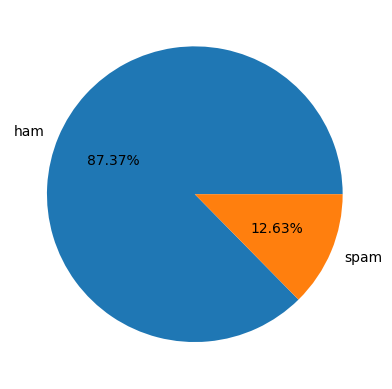

In [87]:
import matplotlib.pyplot as plt
labels = ['ham', 'spam']
plt.pie(df['target'].value_counts(), labels=labels, autopct='%.2f%%')
plt.plot()

In [88]:
# data is imbalanced
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vanshsingla/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [89]:
# new column for number of chaaracter in each row of text cloumn
df['num_character'] = df['text'].apply(len)
df


,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [90]:
# new column for number of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))


In [91]:
# number of sentences in text column
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [92]:
# find statictics in both ham and spam messges
df[['num_character', 'num_words', 'num_sentences']].describe()

,num_character,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [93]:
# find statictics in ham messages
df[df['target'] == 0][['num_character', 'num_words', 'num_sentences']].describe()

,num_character,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [94]:
# find statictics in spam messages
df[df['target'] == 1][['num_character', 'num_words', 'num_sentences']].describe()

,num_character,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_character', ylabel='Count'>

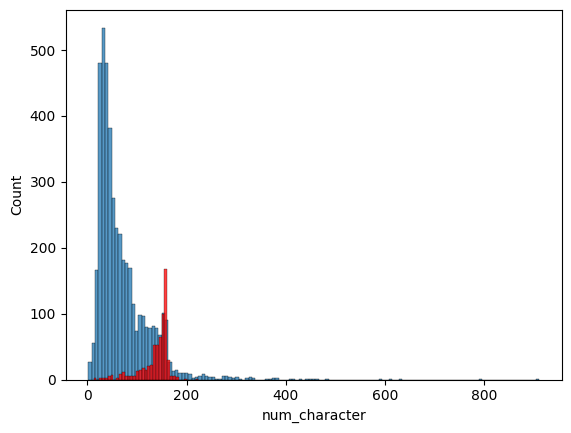

In [95]:
import seaborn as sns
sns.histplot(df[df['target'] == 0]['num_character'])
sns.histplot(df[df['target'] == 1]['num_character'], color='red')

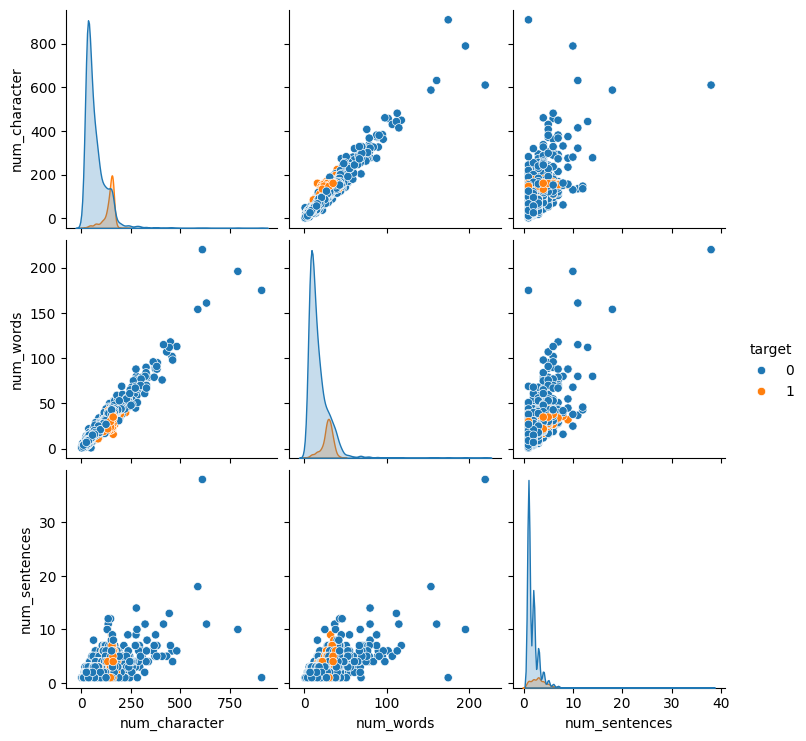

In [96]:
sns.pairplot(df, hue='target')

In [97]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vanshsingla/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [98]:
# creating a function that will help to perform all operation simultaneously

import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [99]:
# make new column of transform text
df['transform_text'] = df['text'].apply(transform_text)

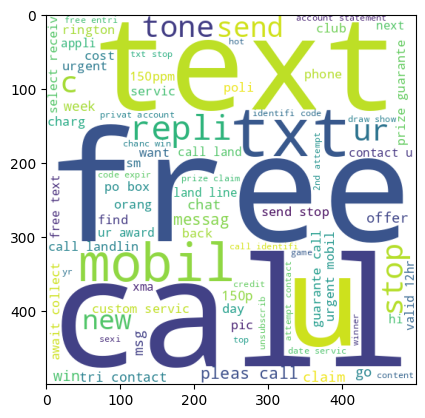

In [100]:
# making of word cloud -> (it makes important word bigger)

# 1. word cloud of spam messages
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc = wc.generate(df[df['target'] == 1]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

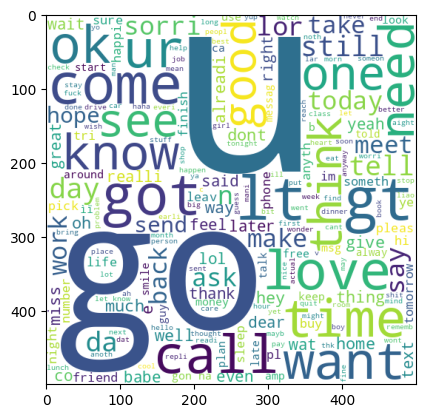

In [101]:
# 2. word cloud of ham messages

from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc = wc.generate(df[df['target'] == 0]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

In [102]:
# total words in spam text is splitted into array

spam_corpus = []
for msg in df[df['target'] == 1]['transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

len(spam_corpus)

9939

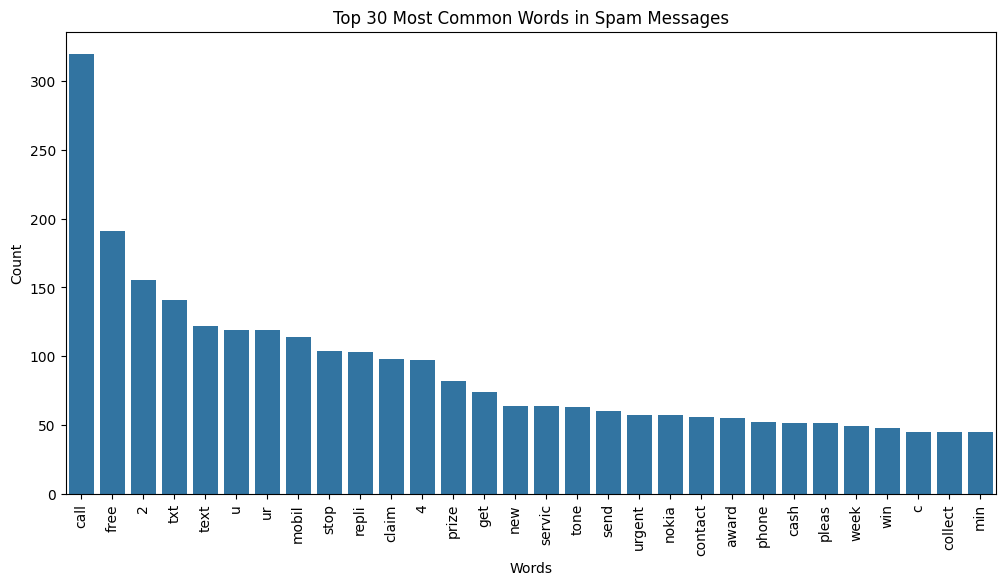

In [103]:
# finding frequency of most common word in spam text

from collections import Counter
Counter(spam_corpus).most_common(30)

most_common_words = Counter(spam_corpus).most_common(30)
new_df = pd.DataFrame(most_common_words)
plt.figure(figsize=(12, 6))  
sns.barplot(x=new_df[0], y=new_df[1])  
plt.xticks(rotation=90)  
plt.title('Top 30 Most Common Words in Spam Messages')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [104]:
# total words in ham text is splitted into array

spam_corpus = []
for msg in df[df['target'] == 0]['transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

len(spam_corpus)

35404

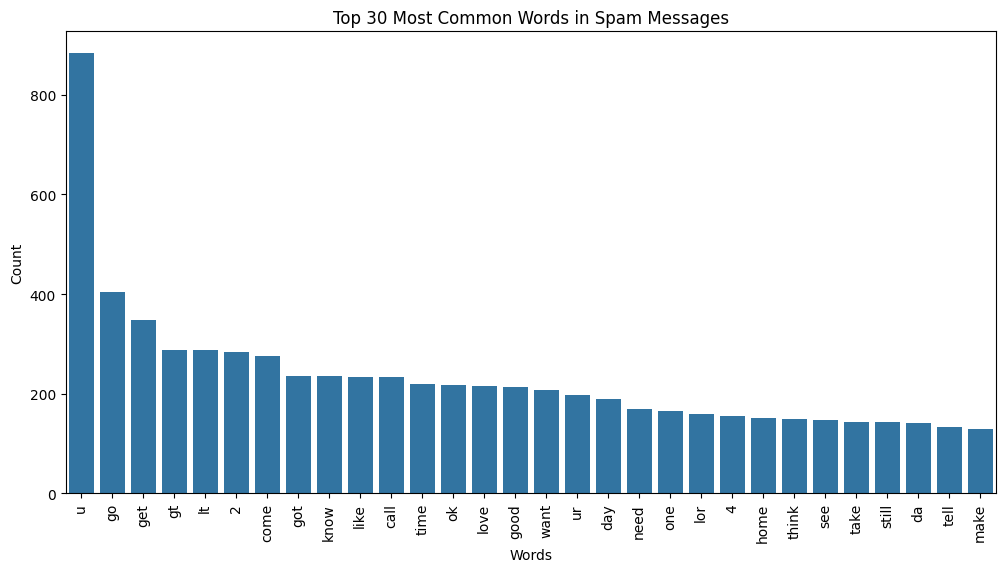

In [105]:
# finding frequency of most common word in ham text

from collections import Counter
Counter(spam_corpus).most_common(30)

most_common_words = Counter(spam_corpus).most_common(30)
new_df = pd.DataFrame(most_common_words)
plt.figure(figsize=(12, 6))  
sns.barplot(x=new_df[0], y=new_df[1])  
plt.xticks(rotation=90)  
plt.title('Top 30 Most Common Words in Spam Messages')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [106]:
# MODEL TRAINING==========================================================================================================

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.model_selection import train_test_split

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transform_text']).toarray()
Y = df['target'].values

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [107]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [108]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: Runtim

In [109]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vanshsingla/Documents/SMS-SPAM-DETECTION/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: Runtim

In [110]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))